In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
customers = pd.read_csv('../data/raw/customers.csv')

In [158]:
customers.head()

,customer_id,first_name,city,segment,signup_date
0,1,Customer_1,Dresden,Corporate,2024-02-01
1,2,Customer_2,Cologne,Consumer,2025-12-17
2,3,Customer_3,Leipzig,Consumer,2024-04-04
3,4,Customer_4,Frankfurt,Consumer,2023-03-02
4,5,Customer_5,Dresden,Consumer,2024-01-04


In [159]:
customers_clean = customers.drop_duplicates()
customers_clean.shape

(5000, 5)

In [160]:
customers_clean[customers_clean.isnull().any(axis=1)]

,customer_id,first_name,city,segment,signup_date
117,118,Customer_118,NaN,Consumer,2023-12-31
842,843,Customer_843,Dresden,NaN,2023-03-04


In [161]:
orders = pd.read_csv('../data/raw/orders.csv')
orders.head()

,order_id,customer_id,order_date,status,payment_method
0,1,4582,2025-10-16,Completed,Card
1,2,1461,2024-04-08,Completed,Bank Transfer
2,3,3888,2024-08-12,Completed,Bank Transfer
3,4,293,2024-03-15,Completed,PayPal
4,5,1644,2025-12-10,Completed,Card


In [162]:
orders[orders['customer_id'].isin([118, 843])]

,order_id,customer_id,order_date,status,payment_method
3139,3140,118,2025-06-21,Completed,Card
10803,10804,118,2025-11-15,Completed,Card
13127,13128,118,2024-11-21,Completed,Card
16558,16559,118,2024-10-04,Completed,Card
17626,17627,118,2025-08-13,Completed,PayPal


In [163]:
customers_clean['city'].value_counts(dropna=False)

city
Berlin        533
Leipzig       516
Hamburg       513
Stuttgart     513
Frankfurt     507
Bremen        496
Cologne       486
Düsseldorf    486
Dresden       479
Munich        470
NaN             1
Name: count, dtype: int64

In [164]:
customers_clean['segment'].value_counts(dropna=False)

segment
Consumer          3218
Corporate         1054
Small Business     727
NaN                  1
Name: count, dtype: int64

In [165]:
products = pd.read_csv('../data/raw/products.csv')
products.head()

,product_id,product_name,category,unit_price
0,1,Product_001,Home,35.24
1,2,Product_002,Books,24.59
2,3,Product_003,Clothing,58.74
3,4,Product_004,Sports,28.13
4,5,Product_005,Beauty,22.34


In [166]:
products_clean = products.copy()

In [167]:
products_clean[products_clean.isnull().any(axis=1)]

,product_id,product_name,category,unit_price
18,19,Product_019,NaN,34.41
54,55,Product_055,Beauty,NaN


In [168]:
order_items = pd.read_csv('../data/raw/order_items.csv')
order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price
0,1,13163,30,1,24.01
1,2,5149,73,1,60.13
2,3,14210,86,3,5.88
3,4,19496,33,2,49.56
4,5,19369,99,1,48.94


In [169]:
order_items[order_items['product_id'].isin([19, 55])]

,order_item_id,order_id,product_id,quantity,unit_price
70,71,5273,55,2,NaN
98,99,14067,55,4,NaN
109,110,15112,55,1,NaN
239,240,10479,19,1,32.73
242,243,12130,55,1,NaN
...,...,...,...,...,...
54891,54892,18032,19,1,34.25
54904,54905,16931,19,2,34.01
54935,54936,2065,55,3,NaN
54970,54971,17161,55,2,NaN


In [170]:
order_items[order_items['unit_price'].isnull()]['product_id'].value_counts()

product_id
55    530
Name: count, dtype: int64

In [171]:
order_items[order_items['product_id'] == 55]['unit_price'].value_counts(dropna=False)

unit_price
NaN    530
Name: count, dtype: int64

In [172]:
order_items['unit_price'].isnull().mean()

np.float64(0.009636188432937584)

In [173]:
order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price
0,1,13163,30,1,24.01
1,2,5149,73,1,60.13
2,3,14210,86,3,5.88
3,4,19496,33,2,49.56
4,5,19369,99,1,48.94


In [174]:
order_items.loc[order_items['unit_price'].isnull(), 'quantity'].sum()

np.int64(892)

In [175]:
products_clean.sort_values('product_id').loc[15:57]

,product_id,product_name,category,unit_price
15,16,Product_016,Sports,29.49
16,17,Product_017,Sports,92.42
17,18,Product_018,Books,14.43
18,19,Product_019,NaN,34.41
19,20,Product_020,Beauty,21.06
20,21,Product_021,Home,27.27
21,22,Product_022,Home,26.52
22,23,Product_023,Home,34.70
23,24,Product_024,Beauty,79.48
24,25,Product_025,Clothing,114.01


In [176]:
order_items[order_items['product_id'] == 19]['unit_price'].value_counts(dropna=False)

unit_price
31.56    6
33.44    5
31.47    5
37.30    5
37.32    4
        ..
37.62    1
33.25    1
36.90    1
34.20    1
34.01    1
Name: count, Length: 410, dtype: int64

In [177]:
order_items[order_items['product_id'] == 19]['order_id'].head()

239    10479
244    19946
253    15651
319    18511
412    16047
Name: order_id, dtype: int64

In [178]:
order_items[order_items['order_id'].isin([239, 10479, 19946, 15651, 18511])]

,order_item_id,order_id,product_id,quantity,unit_price
239,240,10479,19,1,32.73
244,245,19946,19,3,37.27
253,254,15651,19,2,32.02
319,320,18511,19,1,32.02
4280,4281,19946,48,1,51.22
4618,4619,15651,43,1,75.09
5939,5940,239,78,1,18.78
7174,7175,239,99,1,51.87
10609,10610,15651,47,1,24.45
10806,10807,10479,30,1,26.83


In [179]:
order_items[order_items['product_id'] == 55]['unit_price'].value_counts(dropna=False)

unit_price
NaN    530
Name: count, dtype: int64

In [180]:
order_items[order_items['quantity'] <= 0]

,order_item_id,order_id,product_id,quantity,unit_price
3210,3211,19102,72,0,28.91
8888,8889,5131,79,-2,17.82


In [181]:
orders[orders['order_id'].isin([19102, 5131])]

,order_id,customer_id,order_date,status,payment_method
5130,5131,4842,2024-02-11,Completed,Bank Transfer
19101,19102,3553,2024-05-19,Completed,Card


In [182]:
order_items[order_items['order_id'] == 5131]

,order_item_id,order_id,product_id,quantity,unit_price
8888,8889,5131,79,-2,17.82
30960,30961,5131,43,1,80.17


In [183]:
order_items[order_items['order_id'] == 19102]

,order_item_id,order_id,product_id,quantity,unit_price
3210,3211,19102,72,0,28.91
8715,8716,19102,80,1,26.66
31968,31969,19102,37,1,99.98


In [184]:
order_items[order_items['order_item_id'].duplicated(keep=False)]

,order_item_id,order_id,product_id,quantity,unit_price
1000,1001,17632,5,4,20.92
55000,1001,17632,5,4,20.92


In [185]:
order_items[~order_items['product_id'].isin(products['product_id'])]

,order_item_id,order_id,product_id,quantity,unit_price
22222,22223,9937,9999,1,63.38


In [186]:
order_items['unit_price'].sort_values(ascending=False).head(10)

12345    9999.99
50285     210.85
33249     210.76
439       210.70
14522     210.57
14977     210.49
21549     210.48
48508     210.46
40050     210.46
53203     210.43
Name: unit_price, dtype: float64

In [187]:
order_items[order_items['unit_price'] == 9999.99]

,order_item_id,order_id,product_id,quantity,unit_price
12345,12346,13858,76,2,9999.99


In [188]:
products[products['product_id'] == 13858]

,product_id,product_name,category,unit_price


In [189]:
order_items[order_items['product_id'] == 13858]

,order_item_id,order_id,product_id,quantity,unit_price


In [190]:
order_items.loc[order_items['unit_price'] == 9999.99]

,order_item_id,order_id,product_id,quantity,unit_price
12345,12346,13858,76,2,9999.99


In [191]:
products[products['product_id'] == 76]

,product_id,product_name,category,unit_price
75,76,Product_076,Electronics,40.36


In [192]:
orders[orders['order_id'] == 13858]

,order_id,customer_id,order_date,status,payment_method
13857,13858,3003,2024-07-25,Cancelled,Card


In [193]:
order_items[order_items['order_id'] == 13858]

,order_item_id,order_id,product_id,quantity,unit_price
9392,9393,13858,62,3,10.53
12345,12346,13858,76,2,9999.99
14391,14392,13858,68,2,44.30
16109,16110,13858,11,4,74.68
18152,18153,13858,12,3,28.02
22038,22039,13858,32,1,33.15
29345,29346,13858,90,1,30.78
36220,36221,13858,43,2,84.40
47593,47594,13858,81,3,37.35
49443,49444,13858,32,3,29.36


In [194]:
orders[~orders['customer_id'].isin(customers['customer_id'])]

,order_id,customer_id,order_date,status,payment_method
7777,7778,99999,2025-05-31,Returned,Card


In [195]:
orders.isna().sum()

order_id          0
customer_id       0
order_date        0
status            0
payment_method    1
dtype: int64

In [196]:
customers_clean.shape

(5000, 5)

In [197]:
customers_clean = customers_clean.drop_duplicates()

In [198]:
customers_clean.shape

(5000, 5)

In [199]:
customers_clean[customers_clean['city'].isna()]

,customer_id,first_name,city,segment,signup_date
117,118,Customer_118,NaN,Consumer,2023-12-31


In [200]:
customers_clean[customers_clean['segment'].isna()]

,customer_id,first_name,city,segment,signup_date
842,843,Customer_843,Dresden,NaN,2023-03-04


In [201]:
products_clean.head()

,product_id,product_name,category,unit_price
0,1,Product_001,Home,35.24
1,2,Product_002,Books,24.59
2,3,Product_003,Clothing,58.74
3,4,Product_004,Sports,28.13
4,5,Product_005,Beauty,22.34


In [202]:
products_clean[products_clean['product_id'] == 19]

,product_id,product_name,category,unit_price
18,19,Product_019,NaN,34.41


In [203]:
products_clean[products_clean['product_id'] == 55]

,product_id,product_name,category,unit_price
54,55,Product_055,Beauty,NaN


In [204]:
orders_clean = orders.copy()

In [205]:
orders_clean = orders_clean.drop_duplicates()

In [206]:
orders_clean.shape

(20000, 5)

In [207]:
orders_clean.head()

,order_id,customer_id,order_date,status,payment_method
0,1,4582,2025-10-16,Completed,Card
1,2,1461,2024-04-08,Completed,Bank Transfer
2,3,3888,2024-08-12,Completed,Bank Transfer
3,4,293,2024-03-15,Completed,PayPal
4,5,1644,2025-12-10,Completed,Card


In [208]:
orders_clean['status'] = orders_clean['status'].str.capitalize()

In [209]:
orders_clean[orders_clean['payment_method'].isna()]

,order_id,customer_id,order_date,status,payment_method
1234,1235,239,2024-05-06,Completed,NaN


In [210]:
orders_clean[orders_clean['customer_id'] == 99999]

,order_id,customer_id,order_date,status,payment_method
7777,7778,99999,2025-05-31,Returned,Card


In [211]:
order_items_clean = order_items.copy()

In [212]:
order_items_clean = order_items_clean.drop_duplicates()

In [213]:
order_items_clean.shape

(55000, 5)

In [214]:
order_items_clean[order_items_clean['quantity'] <= 0]

,order_item_id,order_id,product_id,quantity,unit_price
3210,3211,19102,72,0,28.91
8888,8889,5131,79,-2,17.82


In [215]:
order_items_clean[~order_items_clean['product_id'].isin(products_clean['product_id'])]

,order_item_id,order_id,product_id,quantity,unit_price
22222,22223,9937,9999,1,63.38


In [216]:
orders_clean['status'].value_counts()

status
Completed    18005
Cancelled     1396
Returned       599
Name: count, dtype: int64

In [217]:
order_items_clean[order_items_clean['quantity'] <= 0].shape

(2, 5)

In [218]:
order_items_clean = order_items_clean[order_items_clean['quantity'] > 0]

In [219]:
order_items_clean.head()

,order_item_id,order_id,product_id,quantity,unit_price
0,1,13163,30,1,24.01
1,2,5149,73,1,60.13
2,3,14210,86,3,5.88
3,4,19496,33,2,49.56
4,5,19369,99,1,48.94


In [220]:
order_items_clean = order_items_clean[order_items_clean['product_id'].isin(products_clean['product_id'])]

In [221]:
order_items_clean = order_items_clean[order_items_clean['unit_price'] != 9999.99]

In [222]:
order_items_clean.shape

(54996, 5)

In [223]:
order_items_clean[order_items_clean['quantity'] <= 0]

,order_item_id,order_id,product_id,quantity,unit_price


In [224]:
order_items_clean[~order_items_clean['product_id'].isin(products['product_id'])]

,order_item_id,order_id,product_id,quantity,unit_price


In [225]:
order_items_clean[order_items_clean['unit_price'] == 9999.99]

,order_item_id,order_id,product_id,quantity,unit_price


In [226]:
orders_clean[~orders_clean['customer_id'].isin(customers_clean['customer_id'])]

,order_id,customer_id,order_date,status,payment_method
7777,7778,99999,2025-05-31,Returned,Card


In [227]:
order_items_clean[~order_items_clean['order_id'].isin(orders_clean['order_id'])]

,order_item_id,order_id,product_id,quantity,unit_price


In [228]:
order_items_clean[
    ~order_items_clean['product_id'].isin(products_clean['product_id'])
]

,order_item_id,order_id,product_id,quantity,unit_price


In [229]:
customers_clean.to_csv('../data/processed/customers_clean.csv', index=False)
products_clean.to_csv('../data/processed/products_clean.csv', index=False)
orders_clean.to_csv('../data/processed/orders_clean.csv', index=False)
order_items_clean.to_csv('../data/processed/order_items_clean.csv', index=False)

In [230]:
order_items_clean['order_id'].nunique()

18732

In [231]:
order_items_clean

,order_item_id,order_id,product_id,quantity,unit_price
0,1,13163,30,1,24.01
1,2,5149,73,1,60.13
2,3,14210,86,3,5.88
3,4,19496,33,2,49.56
4,5,19369,99,1,48.94
...,...,...,...,...,...
54995,54996,8760,69,1,23.02
54996,54997,18831,64,2,15.27
54997,54998,6505,64,2,14.91
54998,54999,1363,69,2,22.66


In [232]:
merged = pd.merge(orders_clean, order_items_clean, how='inner', on='order_id')
merged['revenue'] = merged['quantity'] * merged['unit_price']
merged.loc[merged['status'] == 'Completed', 'revenue'].sum()

np.float64(3433978.3499999996)

In [233]:
merged.head()

,order_id,customer_id,order_date,status,payment_method,order_item_id,product_id,quantity,unit_price,revenue
0,1,4582,2025-10-16,Completed,Card,22886,35,2,21.55,43.10
1,1,4582,2025-10-16,Completed,Card,32150,9,2,29.47,58.94
2,1,4582,2025-10-16,Completed,Card,33861,12,1,29.92,29.92
3,2,1461,2024-04-08,Completed,Bank Transfer,47528,81,1,31.31,31.31
4,3,3888,2024-08-12,Completed,Bank Transfer,54092,93,2,85.74,171.48


In [234]:
merged['order_date'] = pd.to_datetime(merged['order_date'])
merged['year'] = merged['order_date'].dt.year
merged['month'] = merged['order_date'].dt.month
monthly_revenue = merged.loc[merged['status'] == 'Completed', :].groupby(['year', 'month'])['revenue'].sum()

In [235]:
aov = merged.loc[merged['status'] == 'Completed', :].groupby(['year', 'month']).agg({'revenue': 'sum', 'order_id': 'nunique'})
aov['aov'] = aov['revenue'] / aov['order_id']
aov

revenue  order_id         aov
year month                                 
2024 1      144789.20       703  205.959033
     2      135505.13       658  205.934848
     3      156336.28       745  209.847356
     4      149165.07       752  198.357806
     5      137253.16       689  199.206328
     6      130356.17       662  196.912644
     7      151809.55       700  216.870786
     8      155014.66       753  205.862762
     9      154163.14       746  206.653003
     10     152303.40       743  204.984388
     11     140237.65       689  203.537954
     12     136117.42       705  193.074355
2025 1      146410.76       757  193.409194
     2      146887.26       665  220.883098
     3      129533.58       651  198.976313
     4      138355.43       690  200.515116
     5      148470.62       720  206.209194
     6      142943.16       704  203.044261
     7      146365.20       710  206.148169
     8      144090.55       726  198.471832
     9      133002.58       693  191.922915
     10     144353.99       711  203.029522
     11     140229.11       664  211.188419
     12     130285.28       632  206.147595

In [236]:
aov['prev_revenue'] = aov['revenue'].shift(1) 

In [237]:
aov['revenue_change'] = aov['revenue'] - aov['prev_revenue']
aov

revenue  order_id         aov  prev_revenue  revenue_change
year month                                                               
2024 1      144789.20       703  205.959033           NaN             NaN
     2      135505.13       658  205.934848     144789.20        -9284.07
     3      156336.28       745  209.847356     135505.13        20831.15
     4      149165.07       752  198.357806     156336.28        -7171.21
     5      137253.16       689  199.206328     149165.07       -11911.91
     6      130356.17       662  196.912644     137253.16        -6896.99
     7      151809.55       700  216.870786     130356.17        21453.38
     8      155014.66       753  205.862762     151809.55         3205.11
     9      154163.14       746  206.653003     155014.66         -851.52
     10     152303.40       743  204.984388     154163.14        -1859.74
     11     140237.65       689  203.537954     152303.40       -12065.75
     12     136117.42       705  193.074355     140237.65        -4120.23
2025 1      146410.76       757  193.409194     136117.42        10293.34
     2      146887.26       665  220.883098     146410.76          476.50
     3      129533.58       651  198.976313     146887.26       -17353.68
     4      138355.43       690  200.515116     129533.58         8821.85
     5      148470.62       720  206.209194     138355.43        10115.19
     6      142943.16       704  203.044261     148470.62        -5527.46
     7      146365.20       710  206.148169     142943.16         3422.04
     8      144090.55       726  198.471832     146365.20        -2274.65
     9      133002.58       693  191.922915     144090.55       -11087.97
     10     144353.99       711  203.029522     133002.58        11351.41
     11     140229.11       664  211.188419     144353.99        -4124.88
     12     130285.28       632  206.147595     140229.11        -9943.83

In [238]:
aov['revenue_change_pct'] = aov['revenue_change'] / aov['prev_revenue'] * 100
aov['revenue_change_pct']

year  month
2024  1              NaN
      2        -6.412129
      3        15.372960
      4        -4.587041
      5        -7.985723
      6        -5.025014
      7        16.457510
      8         2.111270
      9        -0.549316
      10       -1.206345
      11       -7.922180
      12       -2.938034
2025  1         7.562103
      2         0.325454
      3       -11.814285
      4         6.810473
      5         7.311018
      6        -3.722932
      7         2.393987
      8        -1.554092
      9        -7.695140
      10        8.534729
      11       -2.857476
      12       -7.091131
Name: revenue_change_pct, dtype: float64

In [239]:
merged_products = pd.merge(merged, products, how='inner', on='product_id')

In [259]:
ranked = merged_products.loc[merged_products['status'] == 'Completed', :].groupby(['category', 'product_id']).agg({'revenue': 'sum'})
category_revenue = ranked.reset_index()[['category', 'revenue']]
category_revenue = category_revenue.groupby('category').sum()
category_revenue


,revenue
category,
Beauty,418858.25
Books,404013.36
Clothing,355109.01
Electronics,611625.47
Home,956300.83
Sports,655850.52


In [241]:
ranked['product_rank'] = ranked.groupby(level='category')['revenue'].rank(method='min', ascending=False)
ranked[ranked['product_rank'] <= 3].sort_values(['category', 'product_rank'])

revenue  product_rank
category    product_id                         
Beauty      100          73462.00           1.0
            24           72400.64           2.0
            34           42704.39           3.0
Books       11           62023.54           1.0
            10           53365.80           2.0
            36           41952.20           3.0
Clothing    25           96328.25           1.0
            3            51445.74           2.0
            46           31427.67           3.0
Electronics 37           92718.30           1.0
            65           60358.26           2.0
            83           54890.39           3.0
Home        54          175025.37           1.0
            43           68221.76           2.0
            84           49512.31           3.0
Sports      56          115359.99           1.0
            87           92484.73           2.0
            17           77663.97           3.0

In [242]:
ranked = ranked.reset_index()
ranked

,category,product_id,revenue,product_rank
0,Beauty,5,21210.15,8.0
1,Beauty,8,30819.65,5.0
2,Beauty,20,18654.46,9.0
3,Beauty,24,72400.64,2.0
4,Beauty,27,13908.41,12.0
...,...,...,...,...
94,Sports,85,63511.96,5.0
95,Sports,87,92484.73,2.0
96,Sports,90,27368.46,10.0
97,Sports,93,76559.48,4.0


In [243]:
ranked = ranked.merge(
    products_clean[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

In [244]:
ranked[ranked['product_rank'] <= 3].sort_values(
    ['category', 'product_rank']
)

,category,product_id,revenue,product_rank,product_name
14,Beauty,100,73462.00,1.0,Product_100
3,Beauty,24,72400.64,2.0,Product_024
5,Beauty,34,42704.39,3.0,Product_034
17,Books,11,62023.54,1.0,Product_011
16,Books,10,53365.80,2.0,Product_010
20,Books,36,41952.20,3.0,Product_036
33,Clothing,25,96328.25,1.0,Product_025
30,Clothing,3,51445.74,2.0,Product_003
36,Clothing,46,31427.67,3.0,Product_046
45,Electronics,37,92718.30,1.0,Product_037


In [247]:
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue.head()

,year,month,revenue
0,2024,1,144789.20
1,2024,2,135505.13
2,2024,3,156336.28
3,2024,4,149165.07
4,2024,5,137253.16


In [248]:
monthly_revenue['date'] = pd.to_datetime({'year': monthly_revenue['year'],
                                          'month': monthly_revenue['month'],
                                          'day': '1'})

In [249]:
monthly_revenue

,year,month,revenue,date
0,2024,1,144789.20,2024-01-01
1,2024,2,135505.13,2024-02-01
2,2024,3,156336.28,2024-03-01
3,2024,4,149165.07,2024-04-01
4,2024,5,137253.16,2024-05-01
5,2024,6,130356.17,2024-06-01
6,2024,7,151809.55,2024-07-01
7,2024,8,155014.66,2024-08-01
8,2024,9,154163.14,2024-09-01
9,2024,10,152303.40,2024-10-01


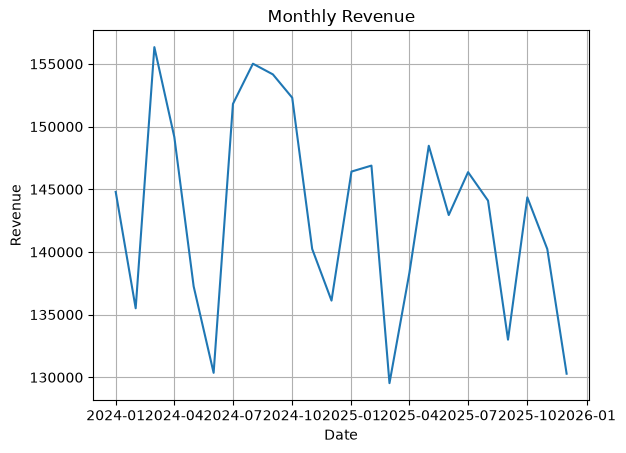

In [254]:
sns.lineplot(data=monthly_revenue, x='date', y='revenue')
plt.title('Monthly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid()

<Axes: xlabel='category', ylabel='revenue'>

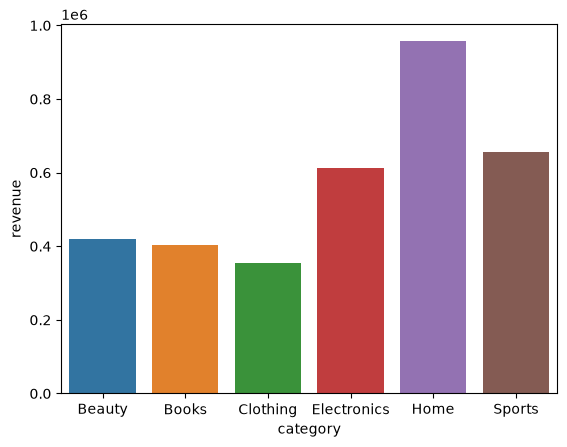

In [261]:
sns.barplot(data=category_revenue, x='category', y='revenue', hue='category')

In [274]:
top_products = merged.groupby('product_id')['revenue'].sum().reset_index()
top_products = top_products.sort_values('revenue', ascending=False).iloc[:10]

<Axes: xlabel='product_id', ylabel='revenue'>

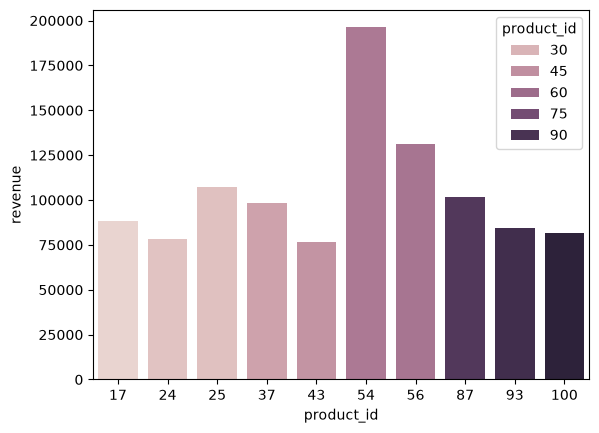

In [276]:
sns.barplot(data=top_products, x='product_id', y='revenue', hue='product_id')

In [283]:
customers_repeated = (
    orders_clean.loc[orders_clean['status'] == 'Completed']
    .groupby('customer_id')['order_id']
    .nunique()
    .reset_index(name='orders_count')
)

customers_repeated


,customer_id,orders_count
0,1,5
1,2,4
2,3,1
3,4,7
4,5,1
...,...,...
4868,4995,3
4869,4996,4
4870,4997,4
4871,4999,3


In [288]:
customers_repeated.loc[customers_repeated['orders_count'] == 1].shape[0]

514

In [294]:
customers_repeated[customers_repeated['orders_count'] > 1].shape[0]

4359

In [296]:
(customers_repeated[customers_repeated['orders_count'] > 1].shape[0]
/ customers_repeated.shape[0]) * 100

89.4520829058075

In [298]:
repeated_not = pd.DataFrame({
    'customer_type': ['One-time', 'Repeat'],
    'customers_count': [514, 4359]
})

In [299]:
repeated_not

,customer_type,customers_count
0,One-time,514
1,Repeat,4359


<Axes: xlabel='customer_type', ylabel='customers_count'>

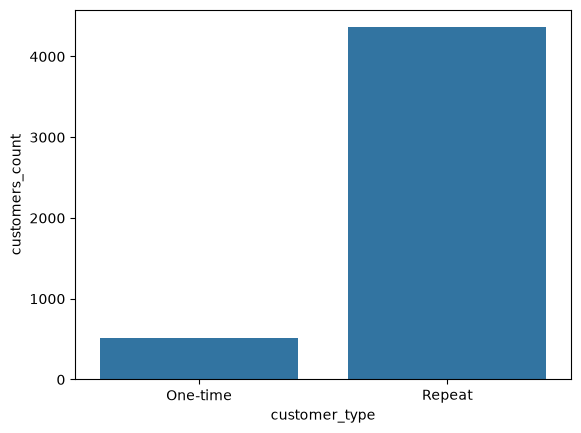

In [300]:
sns.barplot(data=repeated_not, x='customer_type', y='customers_count')